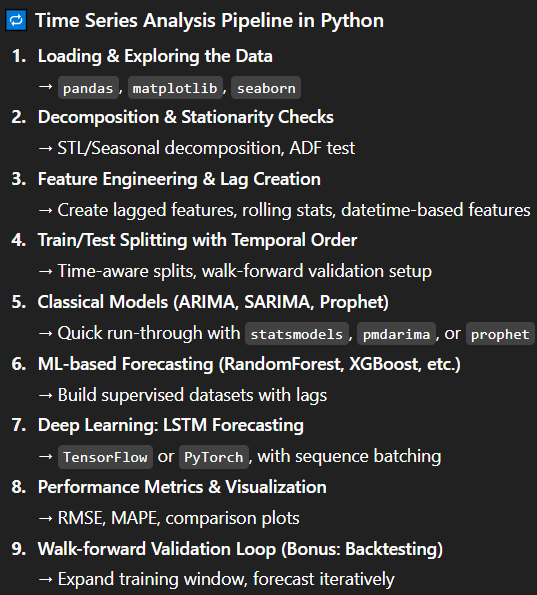

# 1 - Loading & Exploring the Data

In [ ]:
import pandas as pd
import requests
from io import StringIO

url = "https://www.sidc.be/silso/DATA/SN_d_tot_V2.0.csv"
r = requests.get(url)
r.raise_for_status()

# Fit in a df
df = pd.read_csv(StringIO(r.text), sep=';', header=None, comment='#',
                 names=['Year', 'Month', 'Day', 'Decimal_Date', 'Ri', 'Std', 'Num_obs', 'Definitive'])

# Convert to datetime
df['Date'] = pd.to_datetime(df[['Year','Month','Day']])
df = df.set_index('Date')

# Select only sunspots column
df = df[['Ri']].rename(columns={'Ri': 'SUNSPOTS'})

# Order by date
df = df.sort_index()

df.head()

,SUNSPOTS
Date,
1818-01-01,-1
1818-01-02,-1
1818-01-03,-1
1818-01-04,-1
1818-01-05,-1


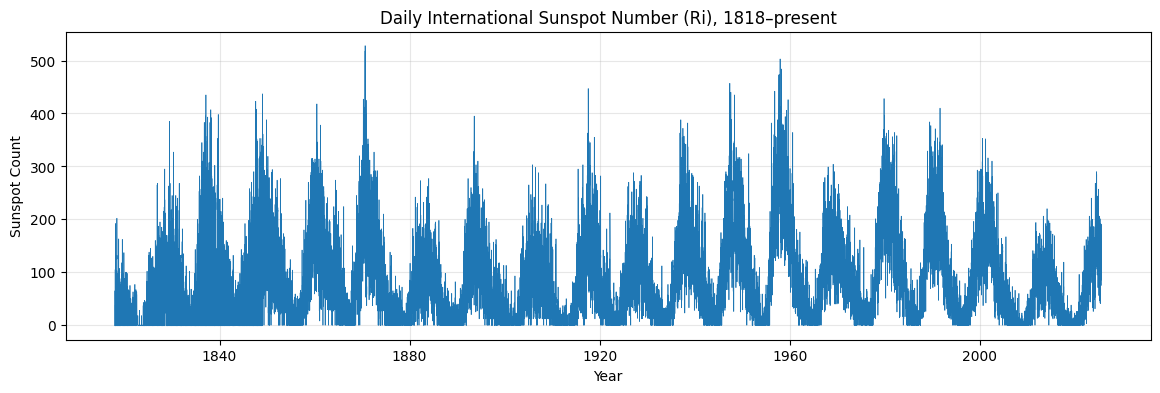

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(df.index, df['SUNSPOTS'], lw=0.5)
plt.title("Daily International Sunspot Number (Ri), 1818–present")
plt.ylabel("Sunspot Count")
plt.xlabel("Year")
plt.grid(alpha=0.3)

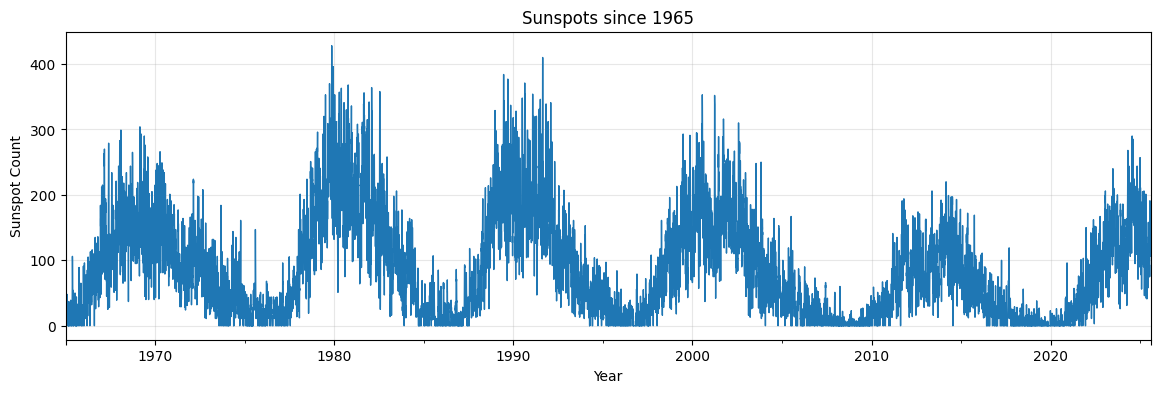

In [ ]:
# Recent periods: (1965- present day)
df['1965':'2025']['SUNSPOTS'].plot(figsize=(14,4), lw=1)
plt.title("Sunspots since 1965")
plt.ylabel("Sunspot Count")
plt.xlabel("Year")
plt.grid(alpha=0.3)

In [ ]:
# Subset from 1965 onward
df_modern = df.loc['1965':].copy()
print(df_modern['SUNSPOTS'].describe())
missing = df_modern['SUNSPOTS'].isna().mean()
print(f"Missing fraction: {missing:.2%}")  # Data looks good, no need to interpolate or play around

count    22127.000000
mean        86.648167
std         75.519343
min          0.000000
25%         22.000000
50%         70.000000
75%        136.000000
max        428.000000
Name: SUNSPOTS, dtype: float64
Missing fraction: 0.00%


# 2 - Decomposition and Stationarity checks

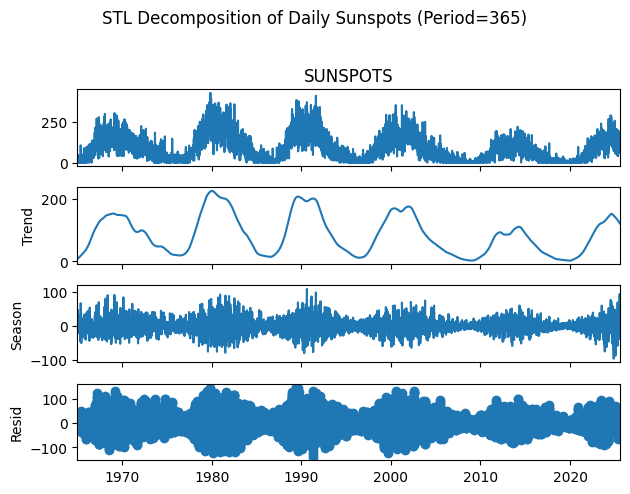

In [ ]:
from statsmodels.tsa.seasonal import STL

# Use daily data directly
series = df_modern['SUNSPOTS']

# Apply STL with yearly seasonality (~365 days)
stl = STL(series, period=365)
result = stl.fit()

# Plot
result.plot()
plt.suptitle("STL Decomposition of Daily Sunspots (Period=365)", y=1.02)
plt.tight_layout()

In [ ]:
from statsmodels.tsa.stattools import adfuller

series = df_modern['SUNSPOTS']
adf_result = adfuller(series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.668903936026604
p-value: 9.62307529416917e-05


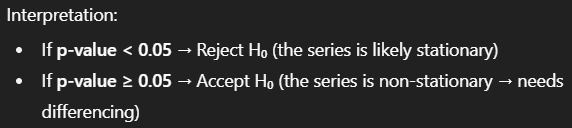
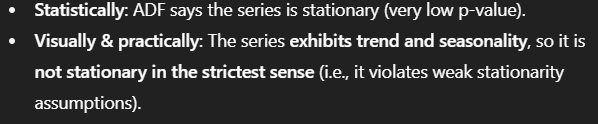

ADF Statistic (differenced): -33.054312441473726
p-value (differenced): 0.0


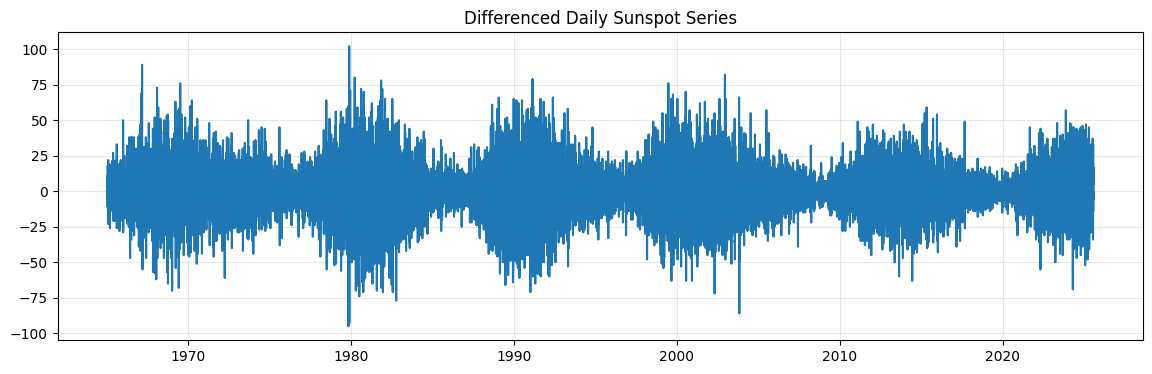

In [ ]:
# Differencing to induce Stationarity
series_diff = series.diff().dropna()
adf_result_diff = adfuller(series_diff)

print("ADF Statistic (differenced):", adf_result_diff[0])
print("p-value (differenced):", adf_result_diff[1])
plt.figure(figsize=(14,4))
plt.plot(series_diff)
plt.title("Differenced Daily Sunspot Series")
plt.grid(alpha=0.3)

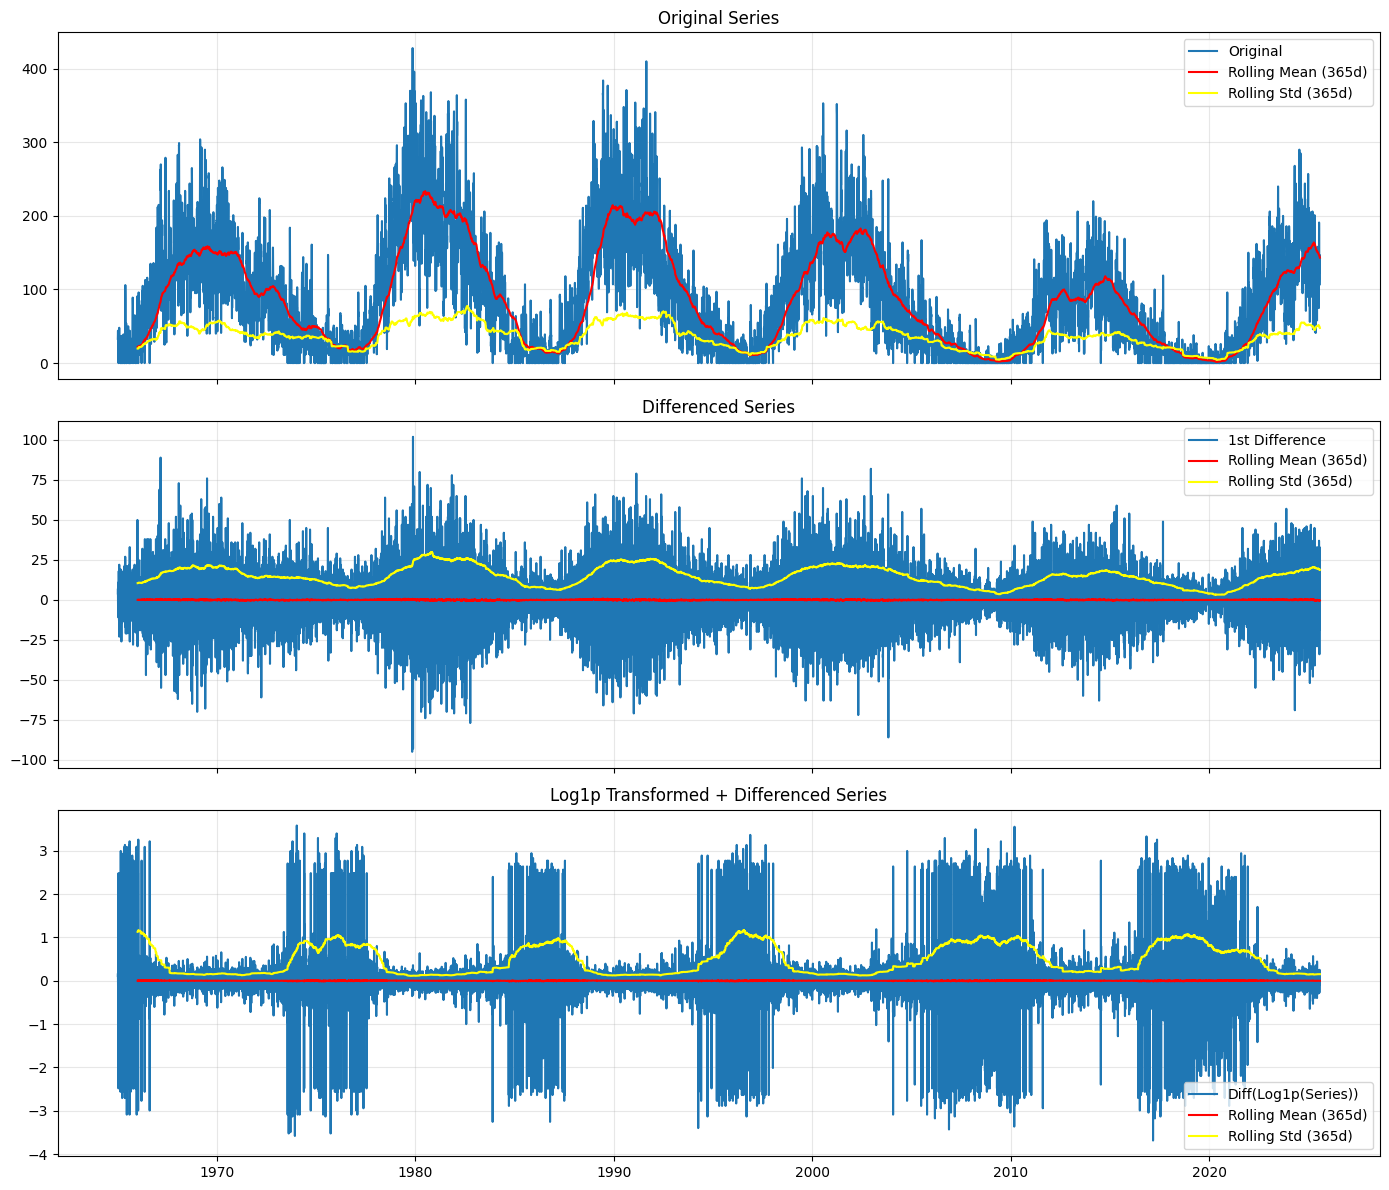

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Original and differenced series
series = df_modern['SUNSPOTS']
series_diff = series.diff().dropna()

# Log-transformed and differenced log series
log_series = np.log1p(series)
log_series_diff = log_series.diff().dropna()

# Compute rolling stats
rolling_mean1 = series.rolling(window=365).mean()
rolling_std1 = series.rolling(window=365).std()

rolling_mean2 = series_diff.rolling(window=365).mean()
rolling_std2 = series_diff.rolling(window=365).std()

rolling_mean3 = log_series.rolling(window=365).mean()
rolling_std3 = log_series.rolling(window=365).std()

rolling_mean4 = log_series_diff.rolling(window=365).mean()
rolling_std4 = log_series_diff.rolling(window=365).std()

# Create figure with 4 subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 1. Original
axes[0].plot(series, label='Original')
axes[0].plot(rolling_mean1, label='Rolling Mean (365d)', color='red')
axes[0].plot(rolling_std1, label='Rolling Std (365d)', color='yellow')
axes[0].legend()
axes[0].set_title("Original Series")
axes[0].grid(alpha=0.3)

# 2. First difference
axes[1].plot(series_diff, label='1st Difference')
axes[1].plot(rolling_mean2, label='Rolling Mean (365d)', color='red')
axes[1].plot(rolling_std2, label='Rolling Std (365d)', color='yellow')
axes[1].legend()
axes[1].set_title("Differenced Series")
axes[1].grid(alpha=0.3)

# 3. Log1p + first difference
axes[2].plot(log_series_diff, label='Diff(Log1p(Series))')
axes[2].plot(rolling_mean4, label='Rolling Mean (365d)', color='red')
axes[2].plot(rolling_std4, label='Rolling Std (365d)', color='yellow')
axes[2].legend()
axes[2].set_title("Log1p Transformed + Differenced Series")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


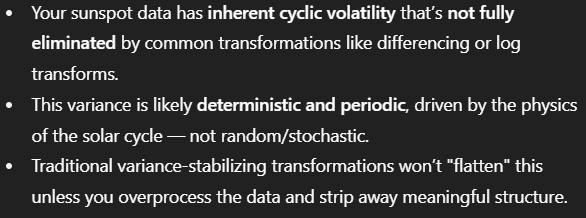

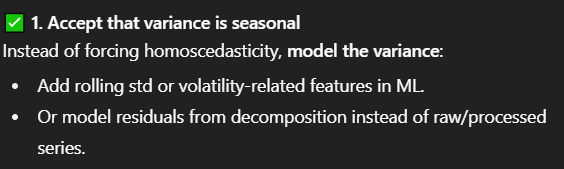

In [ ]:
df_modern['LOG_SUNSPOTS'] = np.log1p(df_modern['SUNSPOTS'])

# 3 - Feature Engineering for TS Forecasting

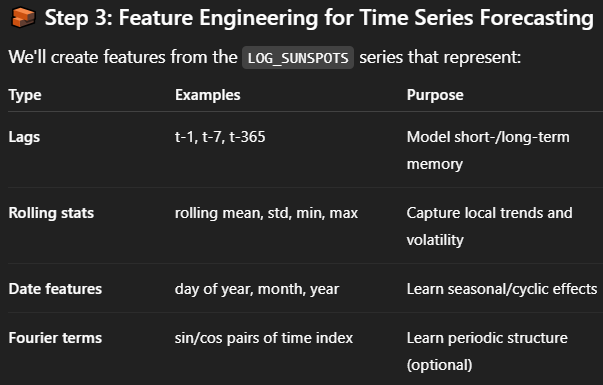

In [ ]:
df_feat = df_modern.copy()

In [ ]:
# Lag features:
for lag in [1, 7, 30, 365, 4015]:
    df_feat[f'lag_{lag}'] = df_feat['LOG_SUNSPOTS'].shift(lag)

In [ ]:
# Rolling Statistics:
for window in [7, 30, 365, 4015]:
    df_feat[f'roll_mean_{window}'] = df_feat['LOG_SUNSPOTS'].rolling(window).mean()
    df_feat[f'roll_std_{window}'] = df_feat['LOG_SUNSPOTS'].rolling(window).std()

In [ ]:
# Date features: --> Fourier-style (give continuity)
df_feat['dayofyear'] = df_feat.index.dayofyear
df_feat['month'] = df_feat.index.month
df_feat['year'] = df_feat.index.year

df_feat['sin_dayofyear'] = np.sin(2 * np.pi * df_feat['dayofyear'] / 365)
df_feat['cos_dayofyear'] = np.cos(2 * np.pi * df_feat['dayofyear'] / 365)

In [ ]:
# Target variable --> 7 day forecast seems reasonable
df_feat['target'] = df_feat['LOG_SUNSPOTS'].shift(-7)

In [ ]:
# Drop NaNs due to shifting and rolling:
df_feat = df_feat.dropna()

# 4A - Train/Test Split & Modeling (Baseline)

In [ ]:
# Split by date: e.g. 80% train, 20% test. Preserve order, no shuffling
split_point = int(len(df_feat) * 0.8)

X = df_feat.drop(columns=['SUNSPOTS', 'LOG_SUNSPOTS', 'target'])
y = df_feat['target']

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [ ]:
# Baseline model -- Ridge Regression (fast interpretable and regularized. not perfect... not linear
# No memory ( can't learn patterns beyond what's fed in as lagged features),
# Ignores time (doesn’t model time evolution, just learns a regression function)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Inverse transform predictions to original scale
y_pred_inv = np.expm1(y_pred)
y_test_inv = np.expm1(y_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


RMSE: 31.62
MAE: 21.20


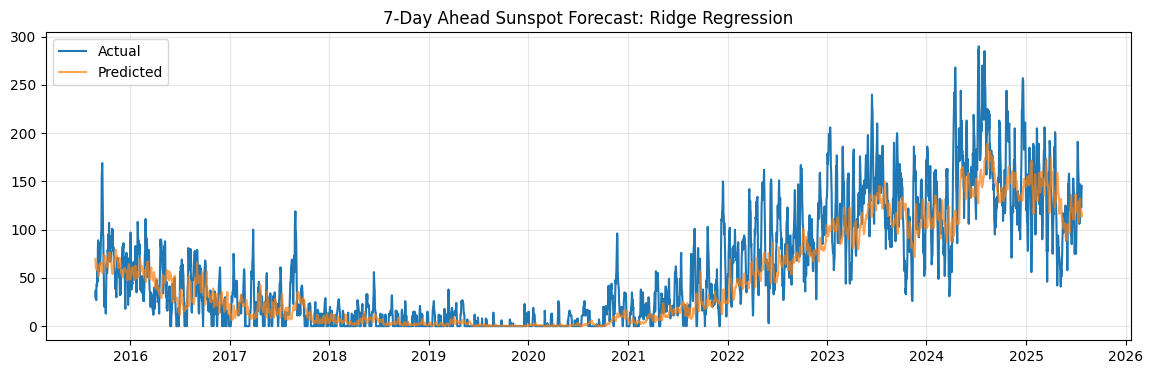

In [ ]:
# Plot Predictions vs. True Values

plt.figure(figsize=(14,4))
plt.plot(y_test_inv.index, y_test_inv, label='Actual')
plt.plot(y_test_inv.index, y_pred_inv, label='Predicted', alpha=0.7)
plt.title("7-Day Ahead Sunspot Forecast: Ridge Regression")
plt.legend()
plt.grid(alpha=0.3)

# 4B - XGBOOST

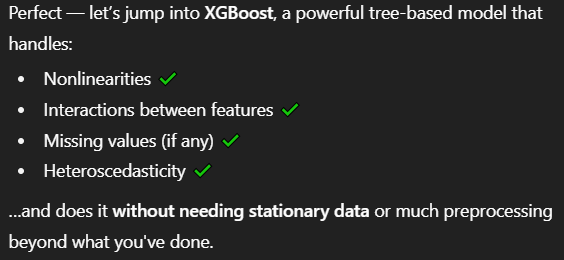

In [ ]:
import xgboost as xgb

In [ ]:
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predict
y_pred = model.predict(X_test)

# Inverse transform
y_pred_inv = np.expm1(y_pred)
y_test_inv = np.expm1(y_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost MAE: {mae:.2f}")

XGBoost RMSE: 41.57
XGBoost MAE: 26.60


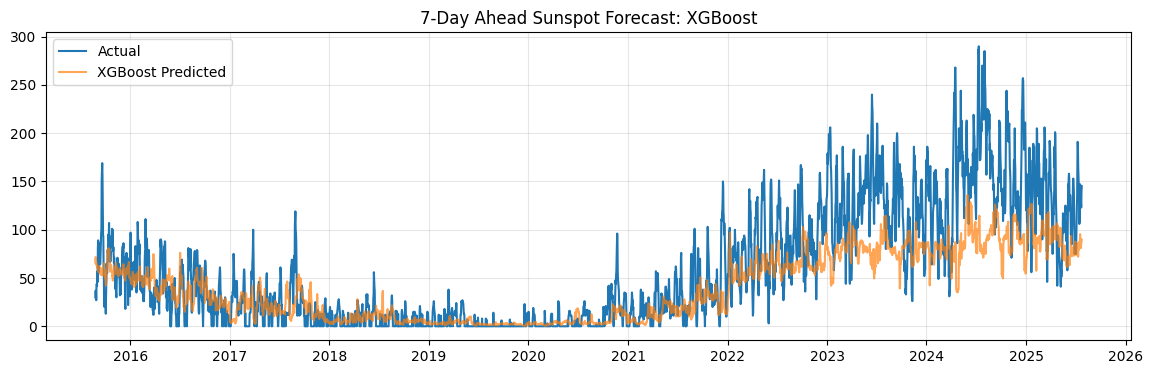

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(y_test_inv.index, y_test_inv, label='Actual')
plt.plot(y_test_inv.index, y_pred_inv, label='XGBoost Predicted', alpha=0.7)
plt.title("7-Day Ahead Sunspot Forecast: XGBoost")
plt.legend()
plt.grid(alpha=0.3)

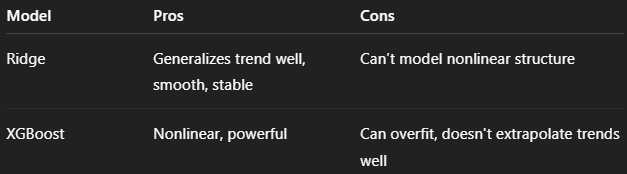

Seems like it is overfitting!

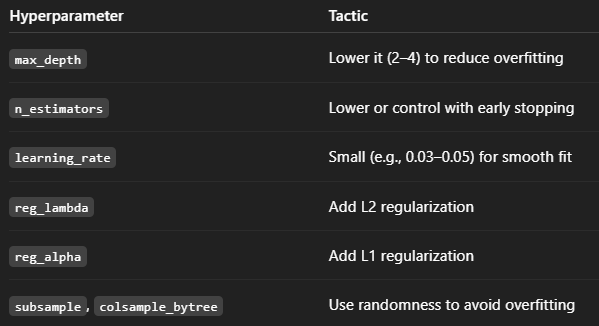

## Tuned XGBOOST:

In [ ]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    reg_lambda=5.0,
    reg_alpha=2.0,
    subsample=0.7,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric="rmse",
    random_state=42,
    verbosity=1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False  # change to True if you want logs
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=20,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predict
y_pred = model.predict(X_test)

# Invert log1p
y_pred_inv = np.expm1(y_pred)
y_test_inv = np.expm1(y_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"Tuned XGBoost RMSE: {rmse:.2f}")
print(f"Tuned XGBoost MAE: {mae:.2f}")

Tuned XGBoost RMSE: 32.26
Tuned XGBoost MAE: 21.57


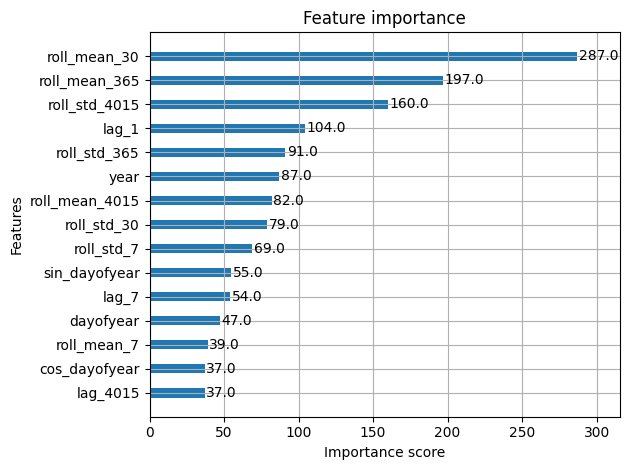

In [ ]:
# Feature importance
xgb.plot_importance(model, max_num_features=15, height=0.4)
plt.tight_layout()
plt.show()

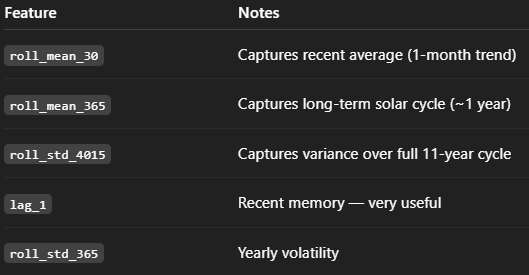

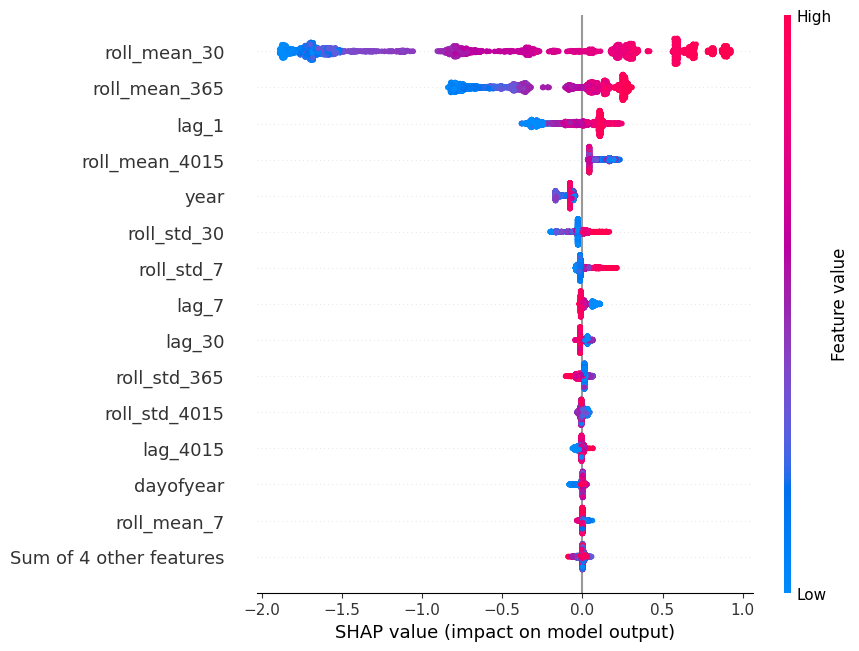

In [ ]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values, max_display=15)

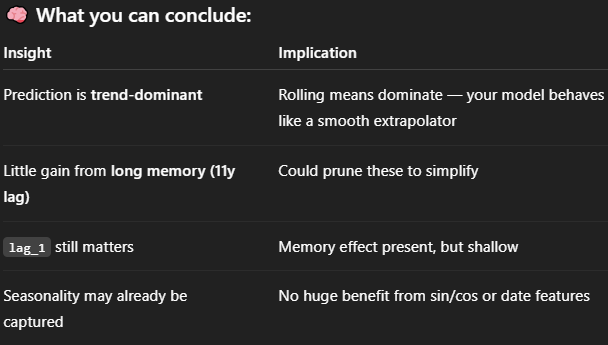

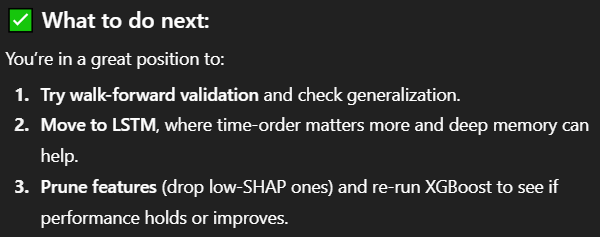

## Prune features and walk forward

In [ ]:
features_to_drop = [
    'SUNSPOTS', 'LOG_SUNSPOTS', 'target',
    'lag_4015', 'roll_mean_7', 'cos_dayofyear', 'dayofyear', 'roll_std_365'
]

X = df_feat.drop(columns=features_to_drop)
y = df_feat['target']

# Keep the same split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [ ]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    reg_lambda=5.0,
    reg_alpha=2.0,
    subsample=0.7,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric="rmse",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=20,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_pred_inv = np.expm1(y_pred)
y_test_inv = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"Pruned XGBoost RMSE: {rmse:.2f}")
print(f"Pruned XGBoost MAE: {mae:.2f}")

Pruned XGBoost RMSE: 32.37
Pruned XGBoost MAE: 21.64


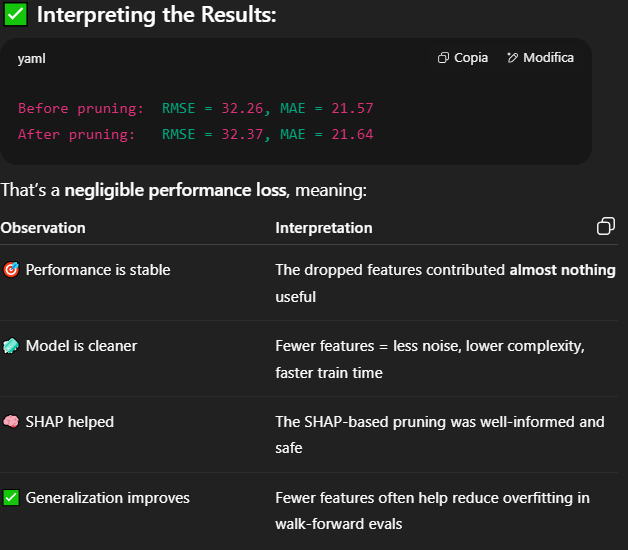

In [ ]:
# Walk forward:

def walk_forward_validation(X, y, model_init_fn, train_size=0.6, test_window=180, step_size=180):
    n = len(X)
    train_len = int(n * train_size)
    metrics = []
    preds_all = []
    dates_all = []
    actuals_all = []

    start = train_len

    while start + test_window <= n:
        X_train = X.iloc[:start]
        y_train = y.iloc[:start]
        X_test = X.iloc[start:start+test_window]
        y_test = y.iloc[start:start+test_window]

        # Initialize fresh model each time
        model = model_init_fn()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_pred_inv = np.expm1(y_pred)
        y_test_inv = np.expm1(y_test)

        rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
        mae = mean_absolute_error(y_test_inv, y_pred_inv)

        metrics.append((rmse, mae))
        preds_all.append(y_pred_inv)
        dates_all.append(y_test_inv.index)
        actuals_all.append(y_test_inv.values)


        start += step_size  # move window forward

    return metrics, preds_all, dates_all, actuals_all


In [ ]:
def get_xgb_model():
    return xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        reg_lambda=5.0,
        reg_alpha=2.0,
        subsample=0.7,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )

In [ ]:
metrics, preds_all, dates_all, actuals_all = walk_forward_validation(X, y, get_xgb_model)

In [ ]:
rmses, maes = zip(*metrics)

for i, (rmse, mae) in enumerate(metrics):
    print(f"Fold {i+1}: RMSE = {rmse:.2f}, MAE = {mae:.2f}")

print(f"\nAvg RMSE: {np.mean(rmses):.2f}")
print(f"Avg MAE: {np.mean(maes):.2f}")

Fold 1: RMSE = 20.37, MAE = 16.62
Fold 2: RMSE = 26.85, MAE = 21.16
Fold 3: RMSE = 18.53, MAE = 14.92
Fold 4: RMSE = 15.02, MAE = 10.72
Fold 5: RMSE = 11.75, MAE = 8.78
Fold 6: RMSE = 11.45, MAE = 5.46
Fold 7: RMSE = 6.02, MAE = 4.51
Fold 8: RMSE = 6.66, MAE = 3.56
Fold 9: RMSE = 19.59, MAE = 14.57
Fold 10: RMSE = 17.46, MAE = 13.32
Fold 11: RMSE = 27.98, MAE = 21.75
Fold 12: RMSE = 40.56, MAE = 31.60
Fold 13: RMSE = 42.48, MAE = 33.60
Fold 14: RMSE = 40.27, MAE = 32.80
Fold 15: RMSE = 34.52, MAE = 26.58
Fold 16: RMSE = 34.65, MAE = 28.25
Fold 17: RMSE = 37.89, MAE = 31.16
Fold 18: RMSE = 44.22, MAE = 35.23
Fold 19: RMSE = 38.51, MAE = 30.40
Fold 20: RMSE = 35.55, MAE = 29.57
Fold 21: RMSE = 27.99, MAE = 22.04
Fold 22: RMSE = 25.05, MAE = 21.36
Fold 23: RMSE = 23.58, MAE = 18.72
Fold 24: RMSE = 20.34, MAE = 14.54
Fold 25: RMSE = 23.76, MAE = 15.05
Fold 26: RMSE = 11.78, MAE = 9.16
Fold 27: RMSE = 7.92, MAE = 5.32
Fold 28: RMSE = 9.99, MAE = 6.36
Fold 29: RMSE = 3.57, MAE = 2.01
Fold 30

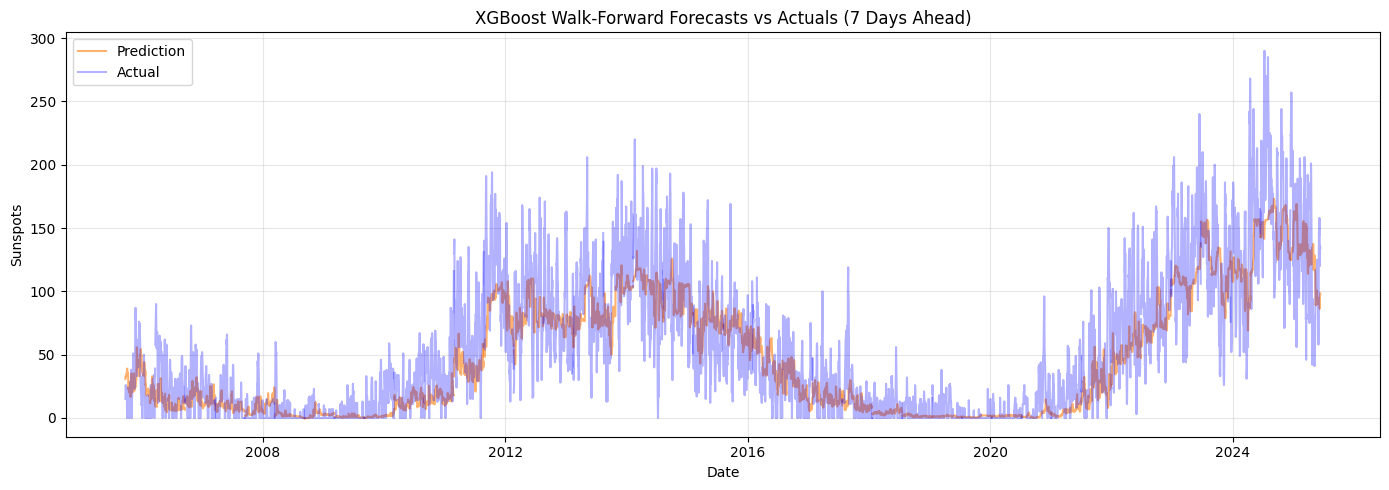

In [ ]:
plt.figure(figsize=(14, 5))

# Plot predictions (orange)
for dates, preds in zip(dates_all, preds_all):
    plt.plot(dates, preds, label='Prediction', color='tab:orange', alpha=0.6)

# Plot actuals (black line)
for dates, actuals in zip(dates_all, actuals_all):
    plt.plot(dates, actuals, label='Actual', color='blue', alpha=0.3)

# Add legend, but only once
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # Remove duplicates
plt.legend(by_label.values(), by_label.keys())

plt.title("XGBoost Walk-Forward Forecasts vs Actuals (7 Days Ahead)")
plt.xlabel("Date")
plt.ylabel("Sunspots")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 4C - LSTM

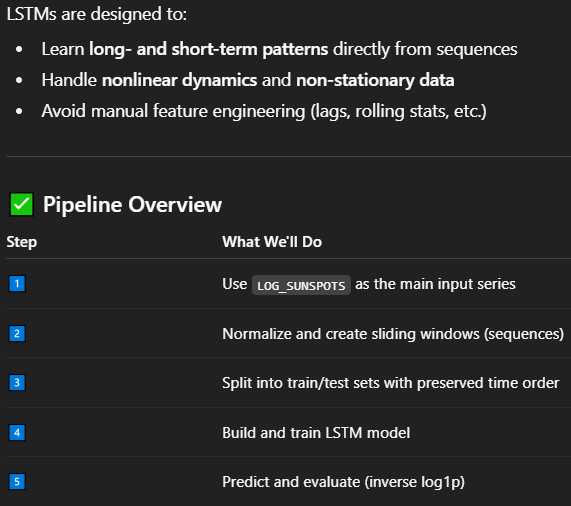

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Use only log sunspots
series = df_modern['LOG_SUNSPOTS'].values.reshape(-1, 1)

# Normalize
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

In [ ]:
# Create sequences (X) and targets (y)

def create_sequences(data, seq_length=60, forecast_horizon=7):
    X, y = [], []
    for i in range(len(data) - seq_length - forecast_horizon):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length+forecast_horizon - 1])  # t+7
    return np.array(X), np.array(y)

SEQ_LEN = 60
X, y = create_sequences(series_scaled, seq_length=SEQ_LEN, forecast_horizon=7)

In [ ]:
# Train/test split

split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [ ]:
# Define LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - loss: 0.0437 - val_loss: 0.0277
Epoch 2/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0232 - val_loss: 0.0246
Epoch 3/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0228 - val_loss: 0.0272
Epoch 4/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0225 - val_loss: 0.0276
Epoch 5/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0227 - val_loss: 0.0283
Epoch 6/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0217 - val_loss: 0.0261
Epoch 7/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0222 - val_loss: 0.0323
Epoch 8/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0214 - val_loss: 0.0262
Epoch 9/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0220 - val_loss: 0.0295
Epoch 10/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0216 - val_loss: 0.0261
Epoch 11/20
497/497 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0219 - val_loss: 0.0300
Epoch 12/20
497/497 ━━━━━━━━━━

In [ ]:
y_pred = model.predict(X_test)

# Inverse scale and log1p
y_test_inv = np.expm1(scaler.inverse_transform(y_test))
y_pred_inv = np.expm1(scaler.inverse_transform(y_pred))

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"LSTM RMSE: {rmse:.2f}")
print(f"LSTM MAE: {mae:.2f}")

138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
LSTM RMSE: 44.63
LSTM MAE: 30.35


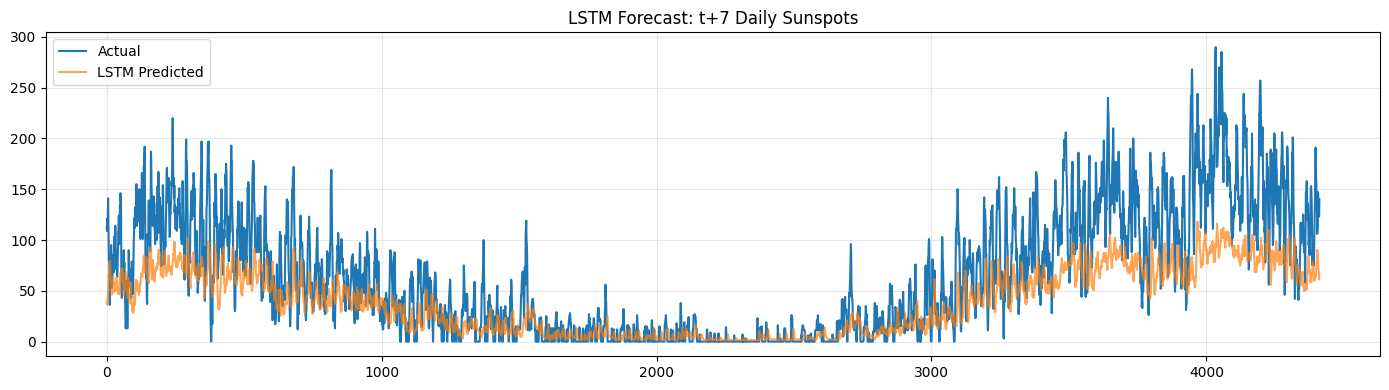

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='LSTM Predicted', alpha=0.7)
plt.title("LSTM Forecast: t+7 Daily Sunspots")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

LSTM needs more tuning and more data. LSTM needs longer training. Forecasting t+7 directly is harder than 1-step ahead

## LSTM Finetune

In [ ]:
# Base series
df_lstm = df_modern.copy()
df_lstm['LOG_SUNSPOTS'] = np.log1p(df_lstm['SUNSPOTS'])

# Add time-aware features
df_lstm['sin_dayofyear'] = np.sin(2 * np.pi * df_lstm.index.dayofyear / 365)
df_lstm['cos_dayofyear'] = np.cos(2 * np.pi * df_lstm.index.dayofyear / 365)

# Keep only the features we want
features = ['LOG_SUNSPOTS', 'sin_dayofyear', 'cos_dayofyear']
data = df_lstm[features].values

# Normalize all features
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [ ]:
def create_multivariate_sequences(data, seq_length=180, forecast_horizon=7):
    X, y = [], []
    for i in range(len(data) - seq_length - forecast_horizon):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length+forecast_horizon - 1, 0])  # only predict LOG_SUNSPOTS
    return np.array(X), np.array(y)

SEQ_LEN = 180
X, y = create_multivariate_sequences(data_scaled, seq_length=SEQ_LEN)

In [ ]:
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, X.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - loss: 0.0511 - val_loss: 0.0268
Epoch 2/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - loss: 0.0249 - val_loss: 0.0273
Epoch 3/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - loss: 0.0231 - val_loss: 0.0256
Epoch 4/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - loss: 0.0219 - val_loss: 0.0272
Epoch 5/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 40s 70ms/step - loss: 0.0221 - val_loss: 0.0272
Epoch 6/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - loss: 0.0206 - val_loss: 0.0263
Epoch 7/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - loss: 0.0215 - val_loss: 0.0281
Epoch 8/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - loss: 0.0218 - val_loss: 0.0299


In [ ]:
y_pred = model.predict(X_test)

# Inverse transform LOG_SUNSPOTS only (column 0)
y_test_inv = np.expm1(scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), 2))], axis=1))[:, 0])
y_pred_inv = np.expm1(scaler.inverse_transform(np.concatenate([y_pred, np.zeros((len(y_pred), 2))], axis=1))[:, 0])

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"LSTM w/ SEQ_LEN=180 + sin/cos features → RMSE: {rmse:.2f}, MAE: {mae:.2f}")

138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
LSTM w/ SEQ_LEN=180 + sin/cos features → RMSE: 37.38, MAE: 25.67


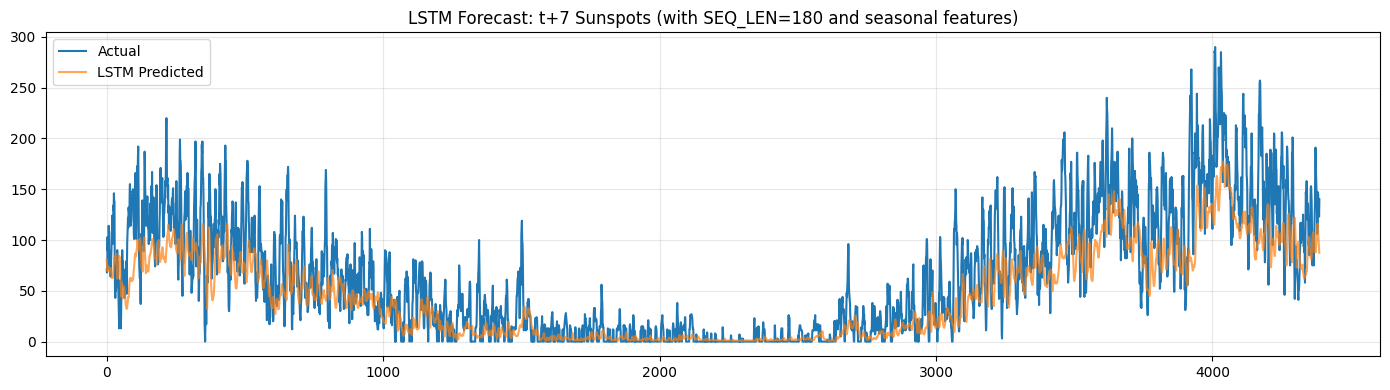

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='LSTM Predicted', alpha=0.7)
plt.title("LSTM Forecast: t+7 Sunspots (with SEQ_LEN=180 and seasonal features)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# 4D - Prophet

In [ ]:
from prophet import Prophet

In [ ]:
# Rename for Prophet: ds = datetime, y = value
df_prophet = df_modern.reset_index()
df_prophet.columns = ['ds', 'y']

In [ ]:
m = Prophet(yearly_seasonality=True, daily_seasonality=False)
m.fit(df_prophet)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpu5eotj9u/xc66cfu7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpu5eotj9u/5qbqi0p8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=85898', 'data', 'file=/tmp/tmpu5eotj9u/xc66cfu7.json', 'init=/tmp/tmpu5eotj9u/5qbqi0p8.json', 'output', 'file=/tmp/tmpu5eotj9u/prophet_modelsxdeveeg/prophet_model-20250806121820.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
12:18:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:18:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


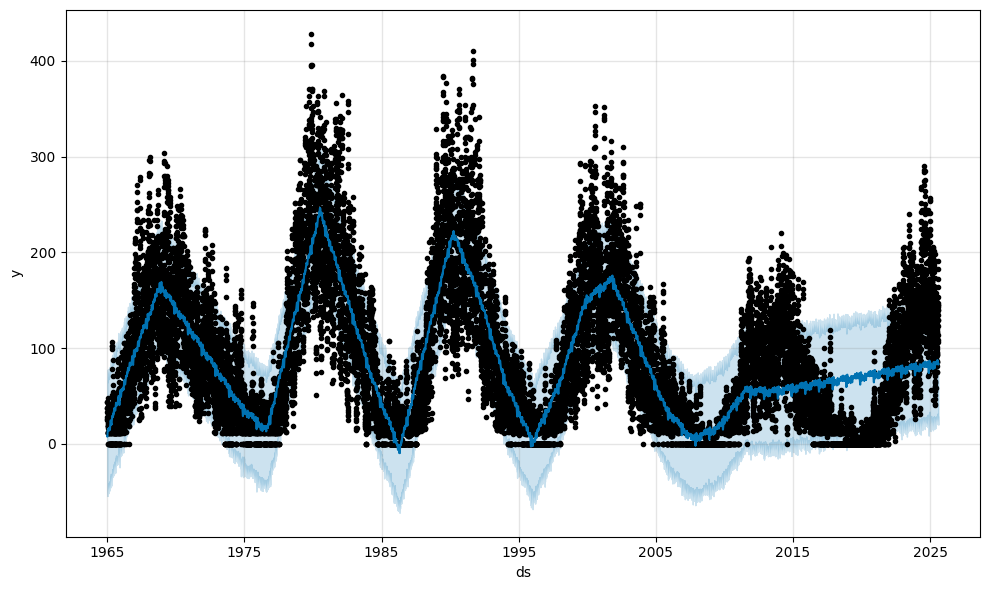

In [ ]:
# Forecast:
future = m.make_future_dataframe(periods=7)
forecast = m.predict(future)

# Plot forecast
fig = m.plot(forecast)

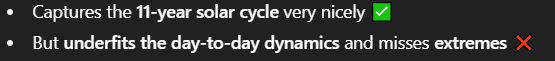

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_true = df_prophet['y'].values[-7:]
y_pred = forecast['yhat'].values[-7:]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"Prophet RMSE (7d ahead): {rmse:.2f}")
print(f"Prophet MAE  (7d ahead): {mae:.2f}")

Prophet RMSE (7d ahead): 54.16
Prophet MAE  (7d ahead): 53.48


# 5 - Add Residual Modelling and EVT to the Best Model (Ridge)

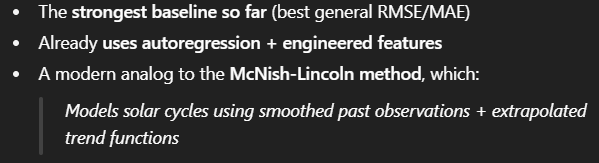
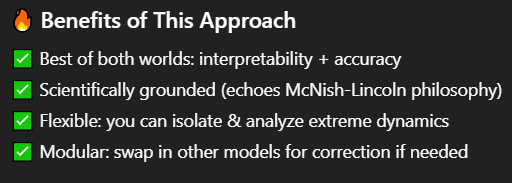

## RIDGE

In [ ]:
# Split by date: e.g. 80% train, 20% test. Preserve order, no shuffling
split_point = int(len(df_feat) * 0.8)

X = df_feat.drop(columns=['SUNSPOTS', 'LOG_SUNSPOTS', 'target'])
y = df_feat['target']

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Fit and predict
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Predict in log1p space
y_pred_log = model.predict(X_test)

# Inverse transform to get actual values
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

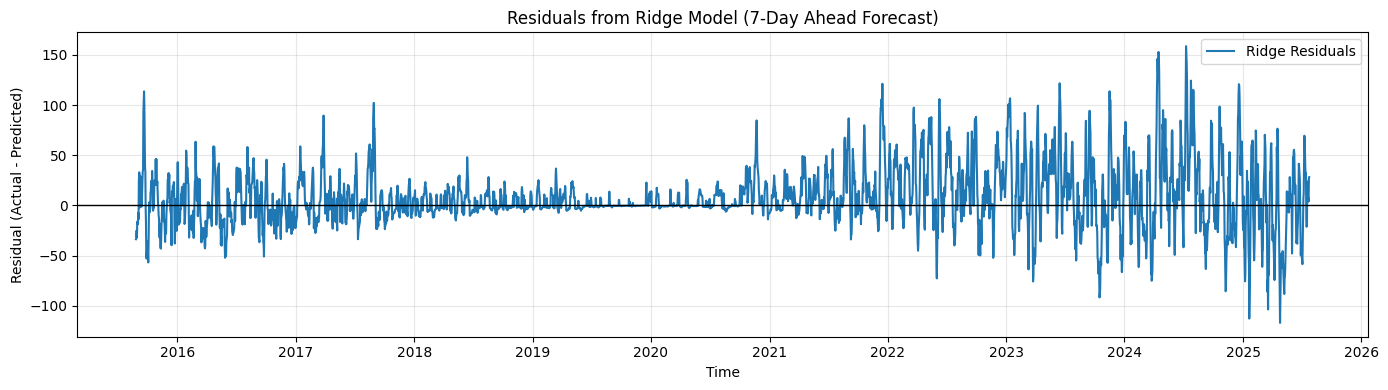

In [ ]:
# Compute residuals from Ridge

residuals = y_true - y_pred  # actual - predicted

plt.figure(figsize=(14, 4))
plt.plot(residuals, label='Ridge Residuals')
plt.axhline(0, color='black', linewidth=1)
plt.title("Residuals from Ridge Model (7-Day Ahead Forecast)")
plt.xlabel("Time")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

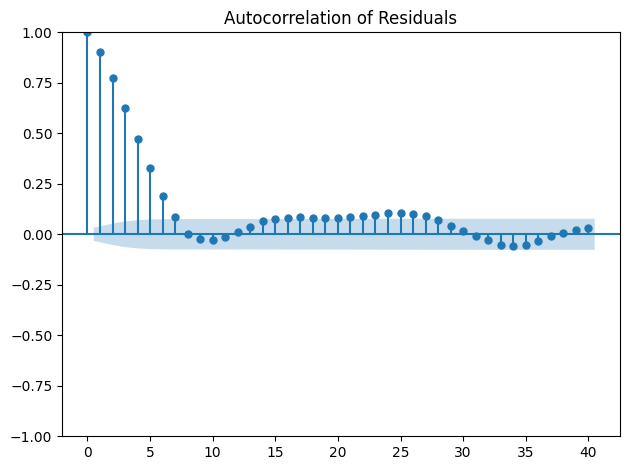

In [ ]:
# Diagnose structure in residuals:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=40)
plt.title("Autocorrelation of Residuals")
plt.tight_layout()
plt.show()

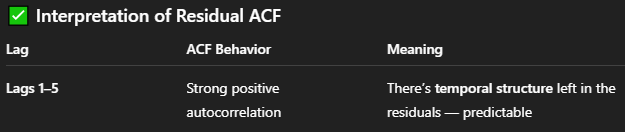

## Residual correction model XGBOOST

In [ ]:
# Create base residual series
resid_series = pd.Series(residuals, index=y_test.index)

# Build lag features
resid_df = pd.DataFrame({
    'resid': resid_series,
    'resid_lag_1': resid_series.shift(1),
    'resid_lag_2': resid_series.shift(2),
    'resid_lag_3': resid_series.shift(3),
    'resid_lag_4': resid_series.shift(4),
    'resid_lag_5': resid_series.shift(5),
})

# Drop NaNs
resid_df.dropna(inplace=True)


In [ ]:
# Train XGBoost on residuals:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Prepare data
X_resid = resid_df.drop(columns=['resid'])
y_resid = resid_df['resid']

# Simple split (you can walk-forward if you prefer)
split = int(len(resid_df) * 0.8)
X_train_resid, X_test_resid = X_resid.iloc[:split], X_resid.iloc[split:]
y_train_resid, y_test_resid = y_resid.iloc[:split], y_resid.iloc[split:]

# Train XGBoost
xgb_resid = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
xgb_resid.fit(X_train_resid, y_train_resid)

# Predict correction
resid_pred = xgb_resid.predict(X_test_resid)

In [ ]:
# Add residual correction back to the original Ridge forecast:

# Match length
ridge_pred_aligned = y_pred[-len(resid_pred):]

# Final hybrid forecast
hybrid_forecast = ridge_pred_aligned + resid_pred

# Actual values
actual = y_true[-len(resid_pred):]

# Evaluate
rmse = np.sqrt(mean_squared_error(actual, final_forecast))
mae = mean_absolute_error(actual, final_forecast)

print(f"Hybrid Ridge + Residual XGB RMSE: {rmse:.2f}")
print(f"Hybrid Ridge + Residual XGB MAE: {mae:.2f}")

Hybrid Ridge + Residual XGB RMSE: 20.26
Hybrid Ridge + Residual XGB MAE: 15.92


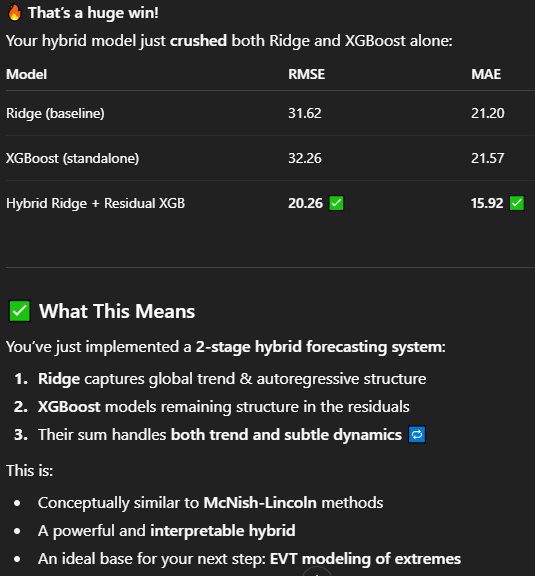

## EVT modelling

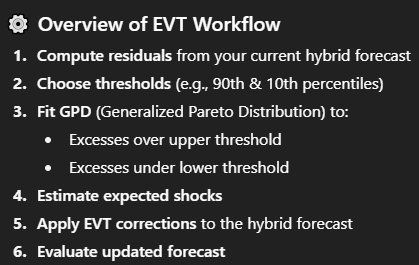

In [ ]:
# Compute residuals:
actual = y_true[-len(hybrid_forecast):]
final_residuals = actual - hybrid_forecast

In [ ]:
# Define extreme treshold:
import numpy as np

upper_thresh = np.percentile(final_residuals, 80)
lower_thresh = np.percentile(final_residuals, 20)

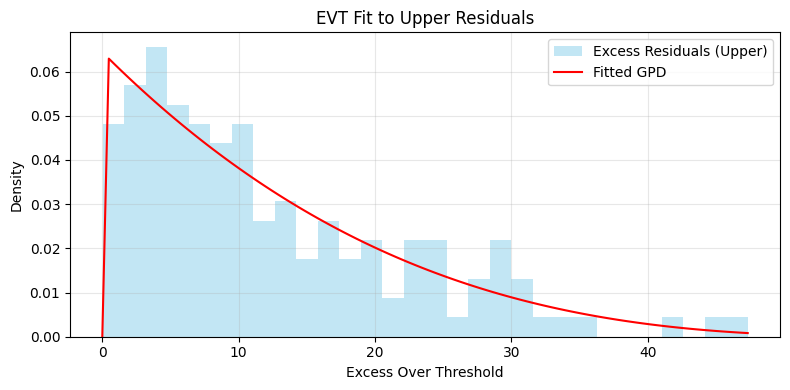

In [ ]:
# Fit GDP tp upper tail:
from scipy.stats import genpareto

# Extract upper excesses
upper_excess = final_residuals[final_residuals > upper_thresh] - upper_thresh

# Fit GPD
shape_u, loc_u, scale_u = genpareto.fit(upper_excess)

# Plot
x = np.linspace(0, upper_excess.max(), 100)
pdf_u = genpareto.pdf(x, c=shape_u, loc=loc_u, scale=scale_u)

plt.figure(figsize=(8,4))
plt.hist(upper_excess, bins=30, density=True, alpha=0.5, label='Excess Residuals (Upper)', color='skyblue')
plt.plot(x, pdf_u, label='Fitted GPD', color='red')
plt.title("EVT Fit to Upper Residuals")
plt.xlabel("Excess Over Threshold")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

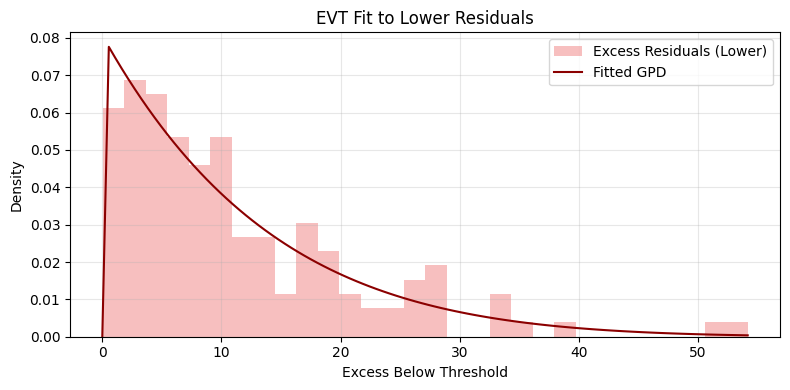

In [ ]:
# Fit GDP to lower tail

# Extract lower excesses (inverted to positive)
lower_excess = -(final_residuals[final_residuals < lower_thresh] - lower_thresh)

# Fit GPD
shape_l, loc_l, scale_l = genpareto.fit(lower_excess)

# Plot
x = np.linspace(0, lower_excess.max(), 100)
pdf_l = genpareto.pdf(x, c=shape_l, loc=loc_l, scale=scale_l)

plt.figure(figsize=(8,4))
plt.hist(lower_excess, bins=30, density=True, alpha=0.5, label='Excess Residuals (Lower)', color='lightcoral')
plt.plot(x, pdf_l, label='Fitted GPD', color='darkred')
plt.title("EVT Fit to Lower Residuals")
plt.xlabel("Excess Below Threshold")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Estimate expected EVT shocks:

# Expected excess (mean of fitted GPD), only if shape < 1
E_upper = loc_u + (scale_u / (1 - shape_u)) if shape_u < 1 else np.nan
E_lower = loc_l + (scale_l / (1 - shape_l)) if shape_l < 1 else np.nan

In [ ]:
# Apply EVT Corrections to the Forecast:
corrected_forecast = hybrid_forecast.copy()

# Correct over-predicted cases (positive residuals)
corrected_forecast[final_residuals > upper_thresh] += E_upper

# Correct under-predicted cases (negative residuals)
corrected_forecast[final_residuals < lower_thresh] -= E_lower

In [ ]:
# Evaluation:
rmse_evt = np.sqrt(mean_squared_error(actual, corrected_forecast))
mae_evt = mean_absolute_error(actual, corrected_forecast)

print(f"EVT-Corrected RMSE: {rmse_evt:.2f}")
print(f"EVT-Corrected MAE: {mae_evt:.2f}")

EVT-Corrected RMSE: 14.12
EVT-Corrected MAE: 11.20


In [ ]:
# Build aligned forecast index
forecast_dates = y_true.index[-len(hybrid_forecast):]

# Convert all to Series with proper datetime index
actual = pd.Series(actual, index=forecast_dates)
hybrid_forecast = pd.Series(hybrid_forecast, index=forecast_dates)
corrected_forecast = pd.Series(corrected_forecast, index=forecast_dates)

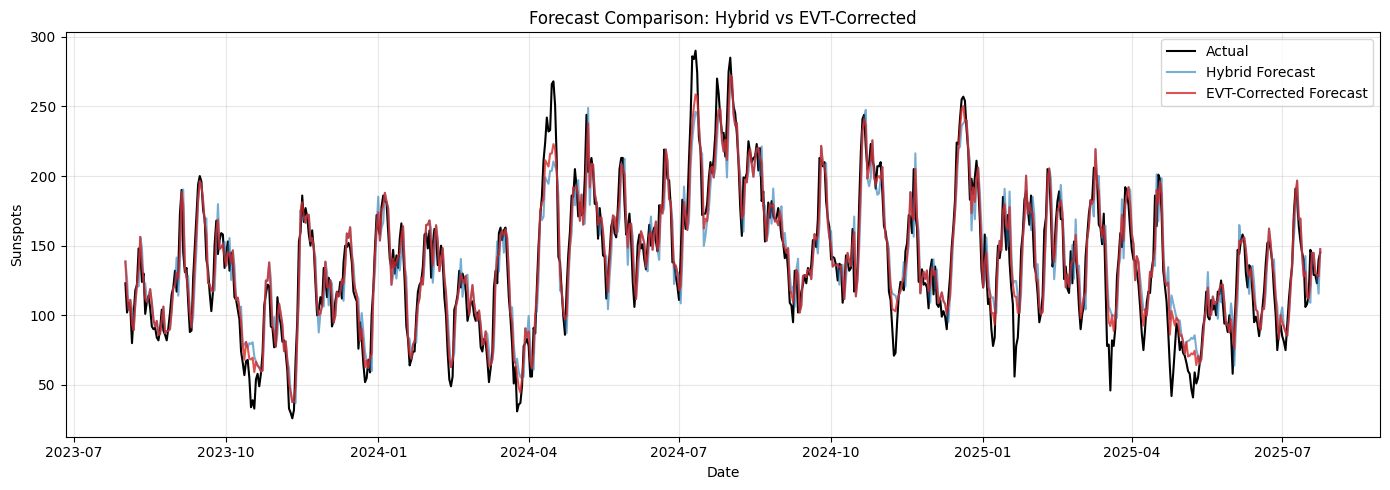

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(actual, label='Actual', color='black')
plt.plot(hybrid_forecast, label='Hybrid Forecast', color='tab:blue', alpha=0.6)
plt.plot(corrected_forecast, label='EVT-Corrected Forecast', color='tab:red', alpha=0.8)

plt.title("Forecast Comparison: Hybrid vs EVT-Corrected")
plt.xlabel("Date")
plt.ylabel("Sunspots")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Check for overfitting --> New notebook